In [1]:
from graph import GraphBuilder, KnowledgeGraph
from concept import ConceptGraph

/people/boufouss/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
builder = GraphBuilder(device = 'cuda:1')

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

## Generation Graphe

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


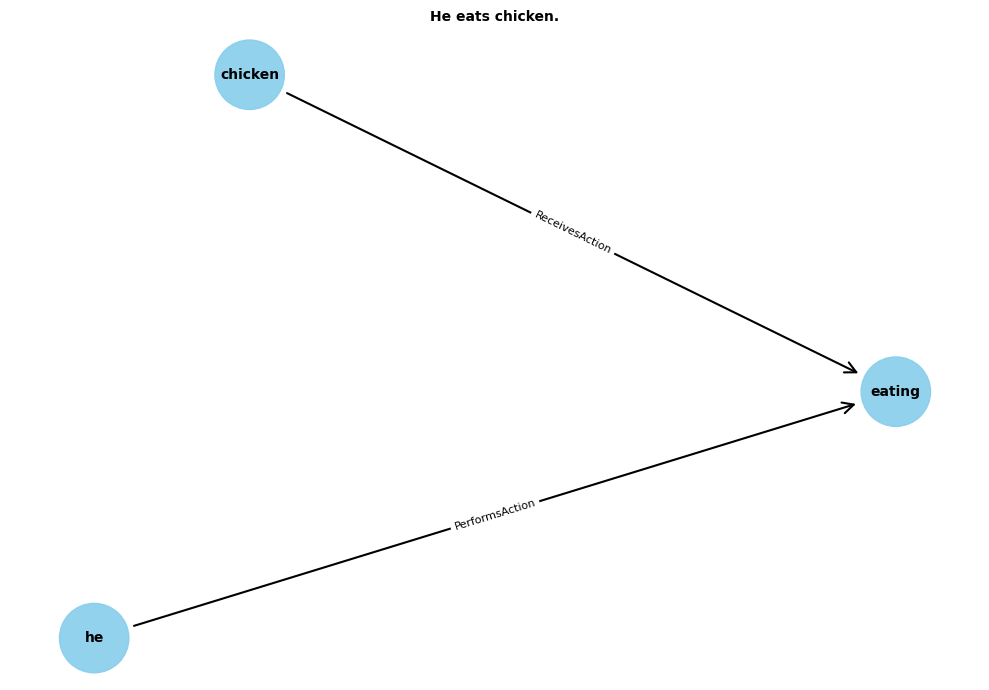

In [3]:
P = builder.build("He eats chicken.")
P.display()

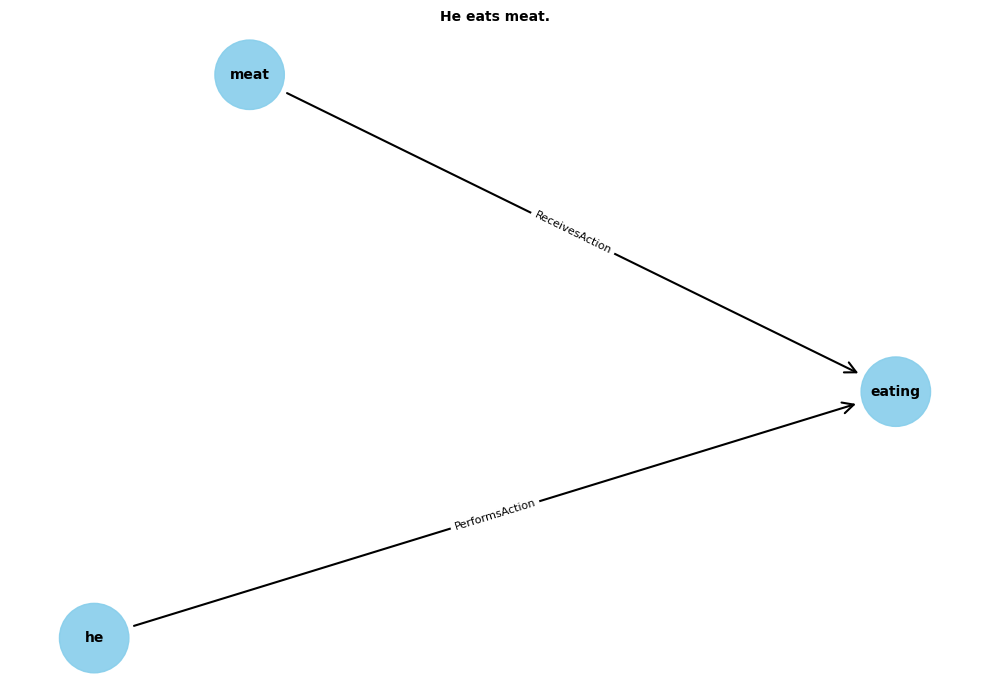

In [4]:
H = builder.build("He eats meat.")
H.display()

## Test recuperer des données

In [5]:
conceptGraph = ConceptGraph('en', device = 'cuda:1')
## ConceptGraph.get_rel_forward('ability')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Ajouter les données naïvement

In [6]:
data_p = conceptGraph.get_rel_naive(P, dist = 1)
data_p[:8], data_p.shape

(array([['chicken', 'RelatedTo', 'bird', 10.768],
        ['eating', 'RelatedTo', 'plate', 9.978],
        ['chicken', 'RelatedTo', 'egg', 9.406],
        ['chicken', 'RelatedTo', 'hen', 8.103],
        ['chicken', 'RelatedTo', 'rooster', 7.657],
        ['chicken', 'RelatedTo', 'animal', 7.6],
        ['chicken', 'CapableOf', 'cross_road', 7.483],
        ['chicken', 'IsA', 'food', 7.211]], dtype=object),
 (100, 4))

Les relations avec le score le plus elevé ne sont pas forcement les plus pertinentes pour lier P à H.

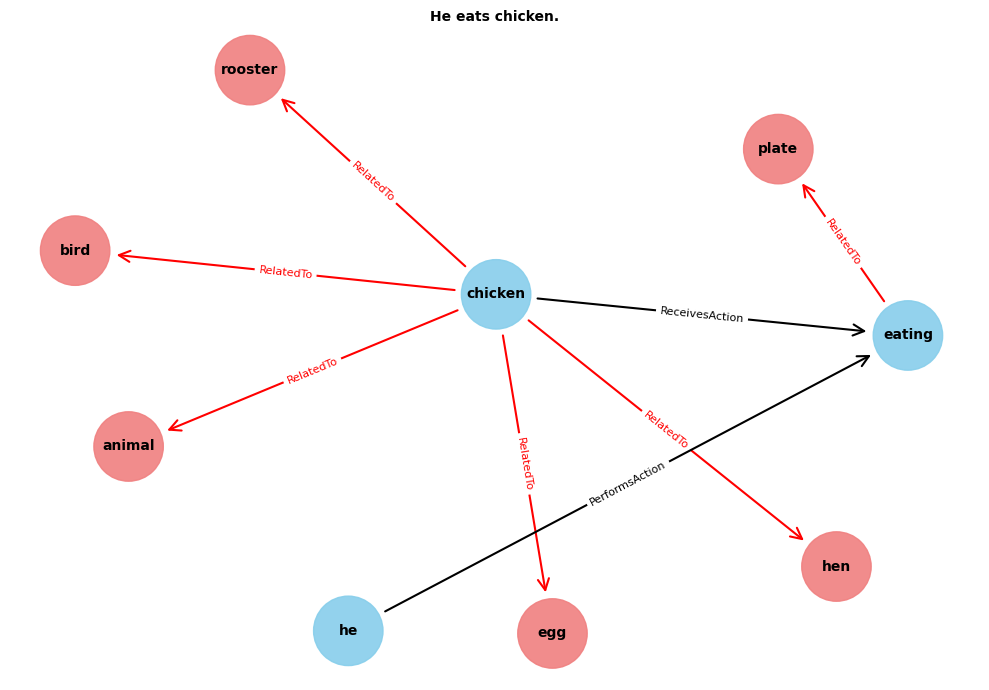

In [7]:
P.augment([(line[0],line[1],line[2])for line in data_p][:6])
P.display()

### Ajouter les données avec un bon score de similarité

In [8]:
P = builder.build("He eats chicken.")

In [9]:
data_p_similarity = conceptGraph.similarity_score(data_p, H)
data_p_similarity[:10], data_p_similarity.shape

(array([['chicken', 'RelatedTo', 'meat', 5.759, 0.5358201265335083],
        ['chicken', 'IsA', 'meat', 6.633, 0.5194038152694702],
        ['chicken', 'RelatedTo', 'eating', 3.394, 0.5092951059341431],
        ['chicken', 'RelatedTo', 'white_meat', 2.542, 0.48845338821411133],
        ['eating', 'RelatedTo', 'squirrel', 2.979, 0.4655943214893341],
        ['eating', 'RelatedTo', 'chicken', 3.394, 0.4629976153373718],
        ['chicken', 'RelatedTo', 'food', 6.887, 0.4442766606807709],
        ['chicken', 'IsA', 'food', 7.211, 0.43267184495925903],
        ['chicken', 'RelatedTo', 'animal', 7.6, 0.42774713039398193],
        ['eating', 'HasPrerequisite', 'food', 2.828, 0.41815289855003357]],
       dtype=object),
 (100, 5))

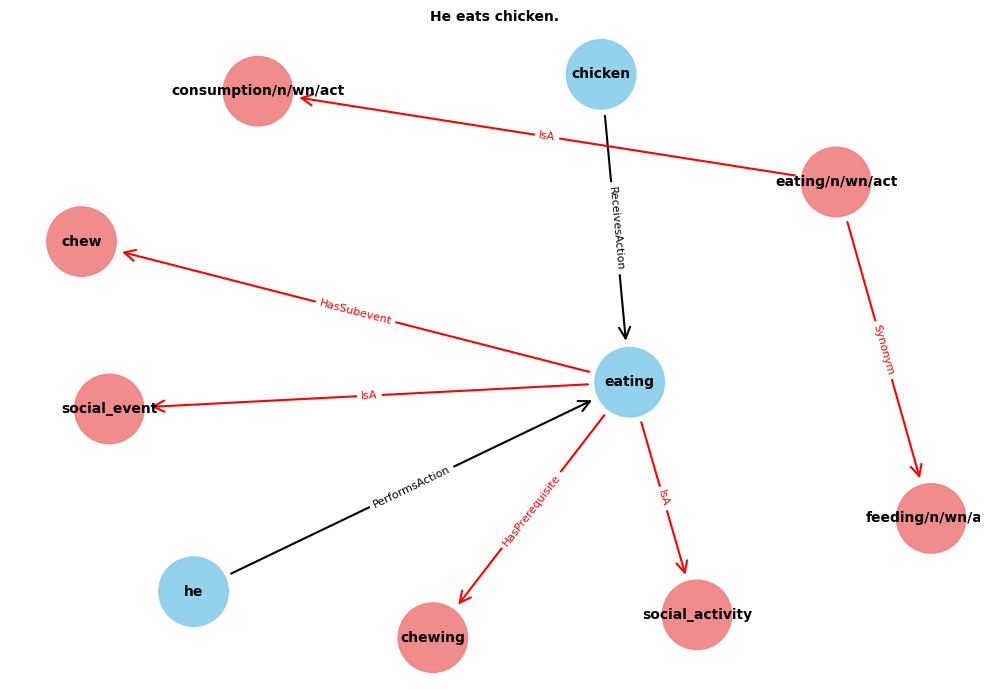

In [12]:
P.augment([(line[0],line[1],line[2])for line in data_p_similarity][:6])
P.display()


Bien mais beaucoup de relations inutiles qui ne menent nulle part, il faut tester de parcourir dans le but d'arriver sur des entitées definies

### Ajouter les données en se concentrant sur la difference entre les graphs

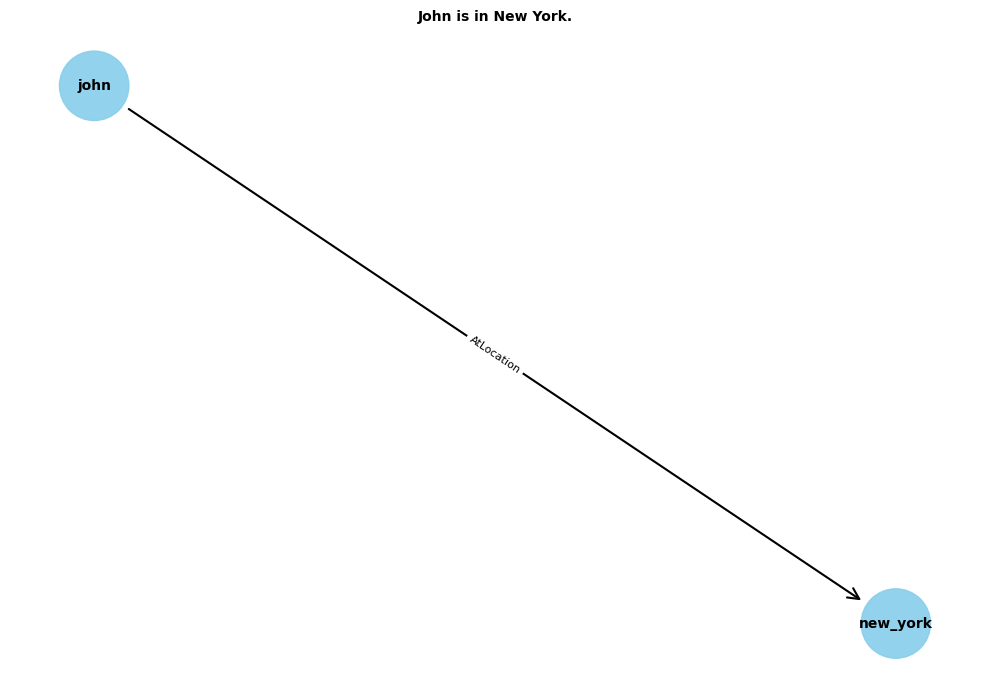

In [13]:
p1 = builder.build("John is in New York.")
p1.display()

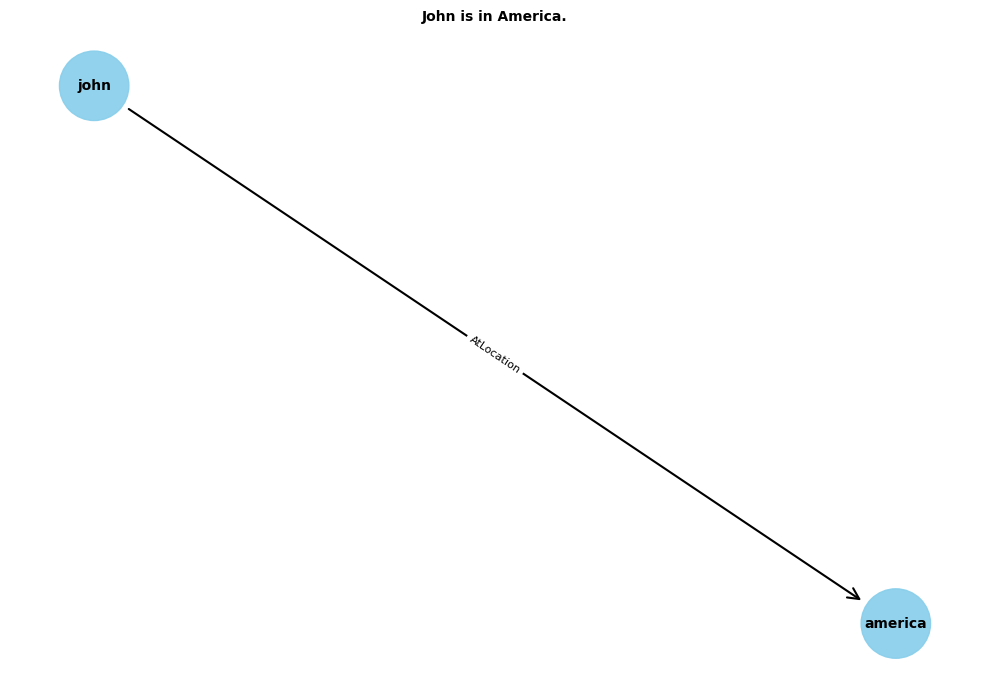

In [14]:
p2 = builder.build("John is in America.")
p2.display()

In [15]:
data_augment = conceptGraph.get_rel_difference(p1, p2, dist = 2)
data_augment

array([['united_states', 'AtLocation', 'america', 2.828],
       ['united_states', 'Synonym', 'america', 2.0],
       ['new_york', 'PartOf', 'united_states', 2.0]], dtype=object)

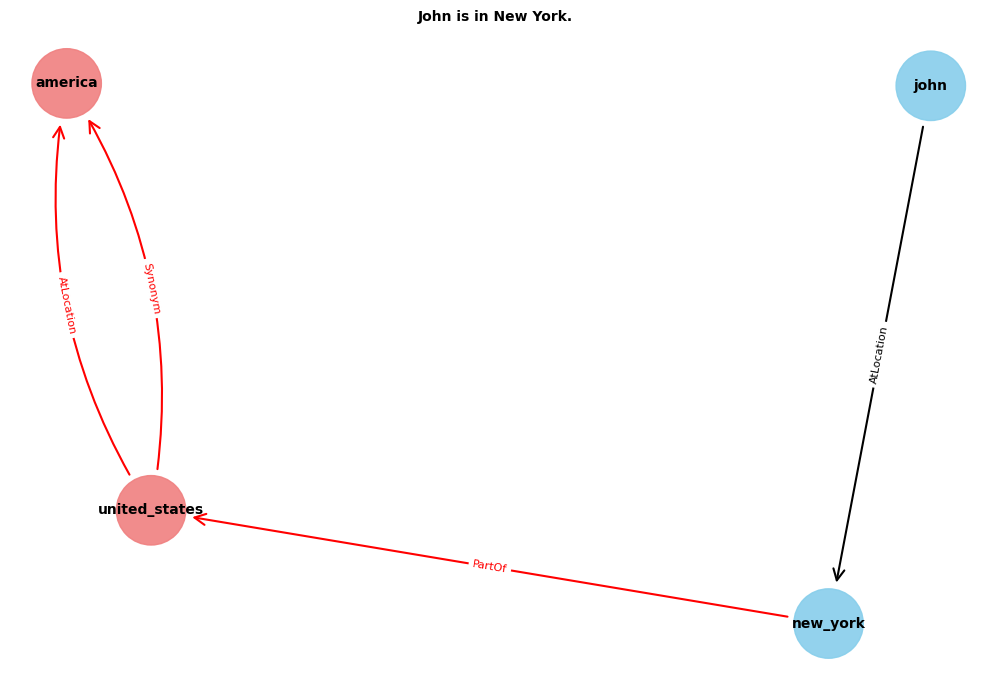

In [16]:
p1.augment([(line[0],line[1],line[2])for line in data_augment])
p1.display()

In [17]:
P = builder.build("He eats chicken.")
H = builder.build("He eats meat.")
data_p_aug = conceptGraph.get_rel_difference(P, H, dist = 1)
data_p_aug


array([['chicken', 'IsA', 'meat', 6.633],
       ['chicken', 'RelatedTo', 'meat', 5.759]], dtype=object)

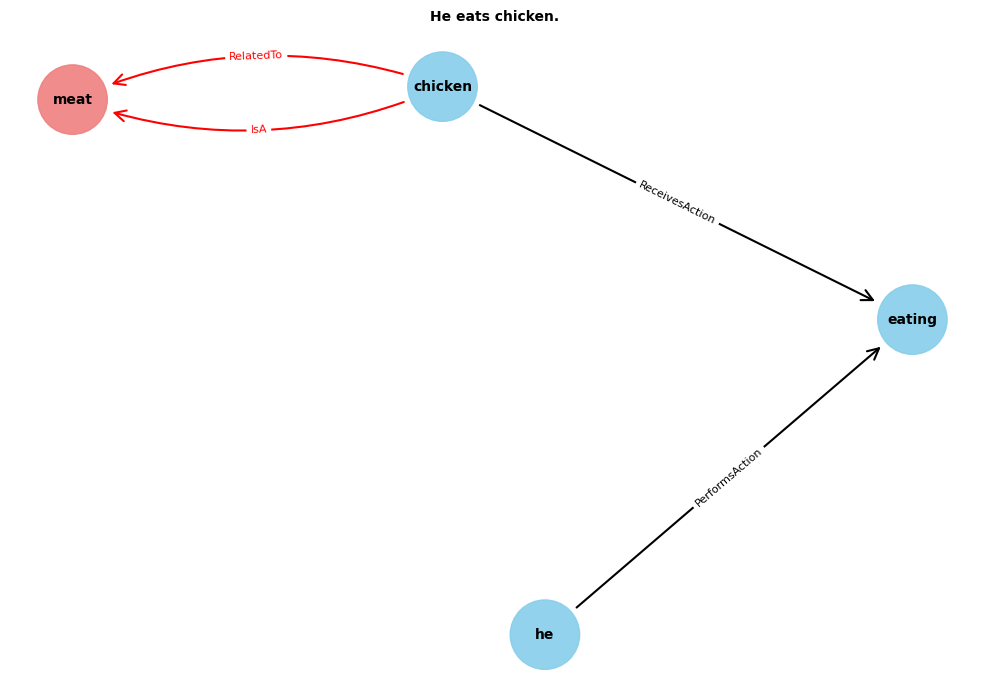

In [18]:
P.augment([(line[0],line[1],line[2])for line in data_p_aug])
P.display()

Marche super bien sur 1 saut, probleme c'est que sur plusieurs sauts, certains sont inutiles (car longs et non pertinents meme si ils menent bien à la target)

Au debut je prenais les n premieres relations, alors qu'il faut prendre les n premiers CHEMINS

Probleme : Ici j'augmente que sur l'ensemble H - P, car je pars du principe qu'il faut se focus sur ce qui est present dans l'hypothese et pas dans la premisse, mais en faisant ça, je pars aussi du principe que l'intersection est resolue, ce qui n'est pas toujours le cas. Exemple : 

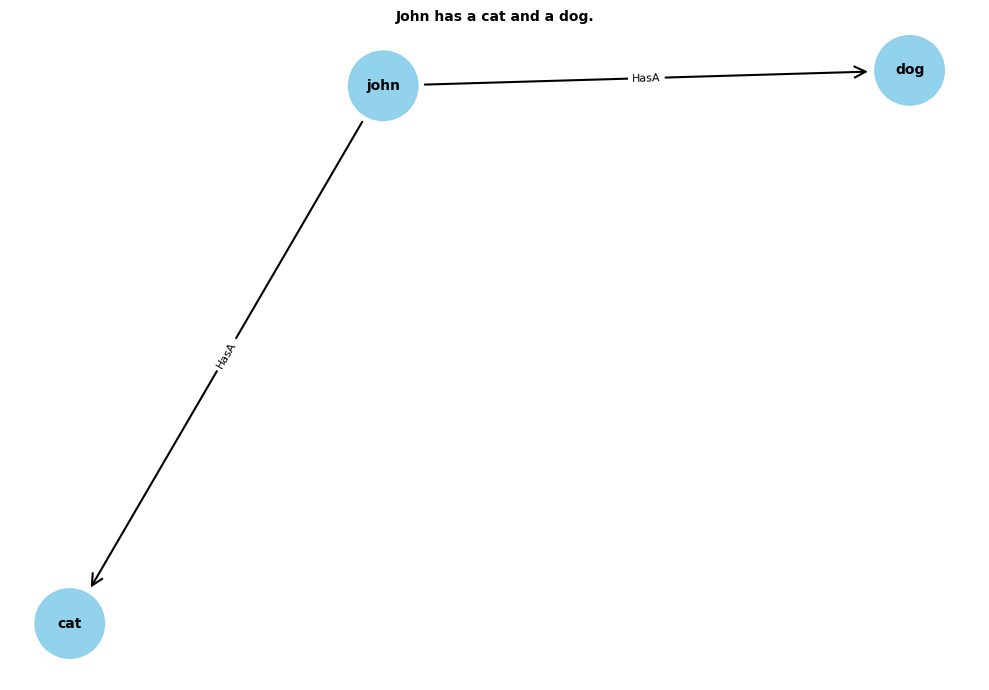

In [19]:
P = builder.build("John has a cat and a dog.")
P.display()

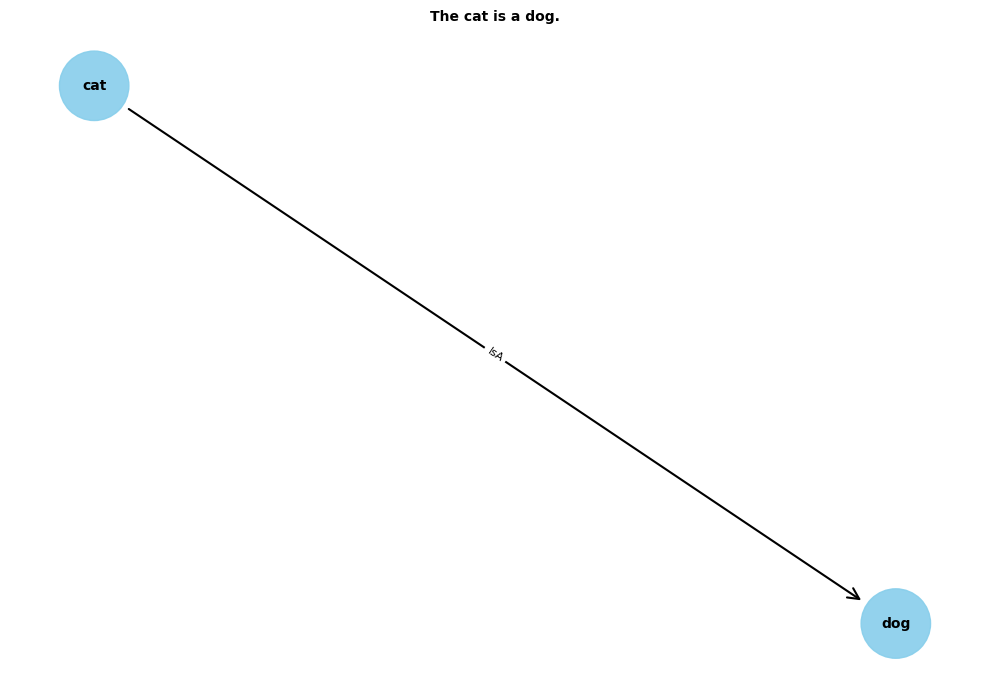

In [20]:
H = builder.build("The cat is a dog.") # add ", and a dog is an animal"
H.display()

In [21]:
data_p_aug = conceptGraph.get_rel_difference(P, H, dist = 1)
data_p_aug

array([], shape=(0, 4), dtype=float64)

En faisant ça l'intersection est vide, alors qu'une donnée vitale pour la decision est : (cat, Antonym, dog). Mais en enlevant l'intersection P inter H, on ne peut pas l'avoir

L'algo ne fait pas de liens entre les données du graph qui sont dans l'intersection seulement quand distance = 1, quand dist=2, il fait des liens entre les données du graphes et les ajoute.
Quand d==1, il test si tail est dans target.entities, ce qui est toujours faux, alors que quand d>1, il part du principe qu'il peux faire des chemins intermediaire, et les chemins interGraphes sont des chemins intermediaires. Il fait ces liens ssi d > 1 et intersection est non vide

In [22]:
conceptGraph.get_rel_nodes(["cat"], rel = ["Antonym"])

,Unnamed: 0,relation,head,tail,weight
274195,379532,Antonym,cat,dog,3.686


In [23]:
conceptGraph.get_rel_nodes(["dog"], rel = ["Antonym"])

,Unnamed: 0,relation,head,tail,weight
237,237,Antonym,dog,cat,3.686


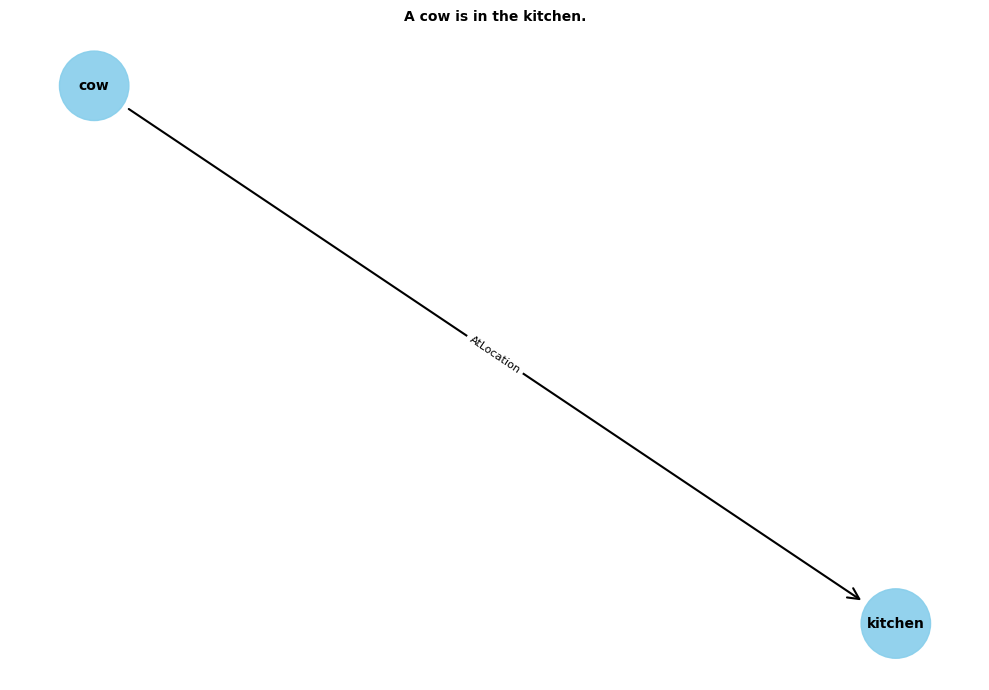

In [38]:
p_v = builder.build("A cow is in the kitchen.")
p_v.display()

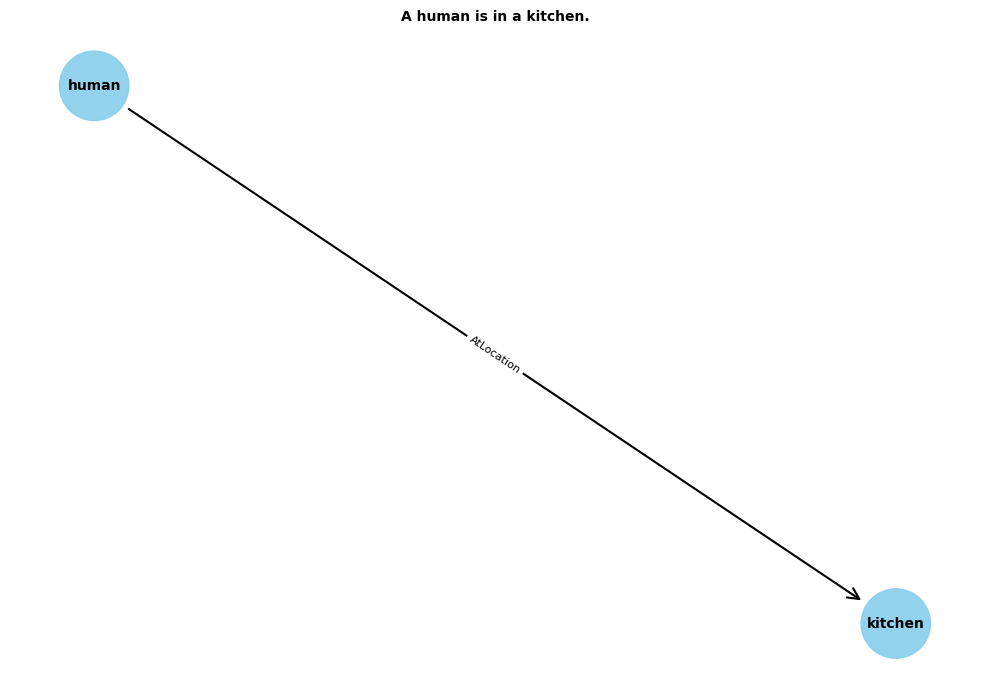

In [39]:
h_v = builder.build("A human is in a kitchen.")
h_v.display()

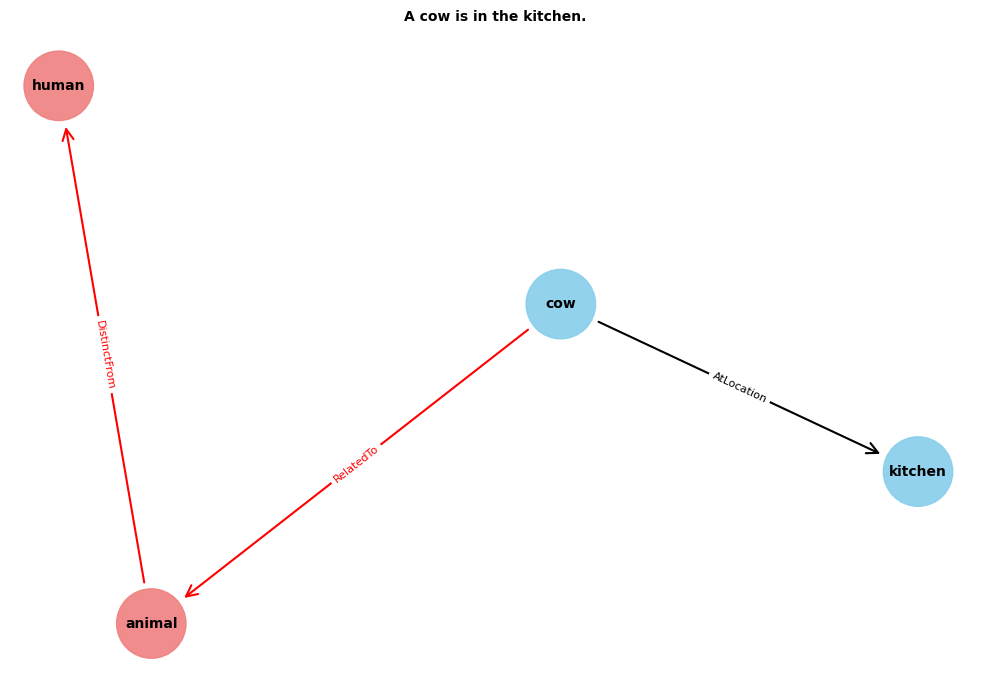

In [40]:
data_v = conceptGraph.get_rel_difference(p_v, h_v, dist = 2)
p_v.augment([(line[0],line[1],line[2])for line in data_v])
p_v.display()

In [27]:
data_test = conceptGraph.get_rel_nodes(["cat"]) # data_test = conceptGraph.get_rel_nodes(["bed"])
data_test[data_test["tail"]=="sleep"]

,Unnamed: 0,relation,head,tail,weight
13838,14844,Desires,cat,sleep,3.464
7113,7568,CapableOf,cat,sleep,3.464


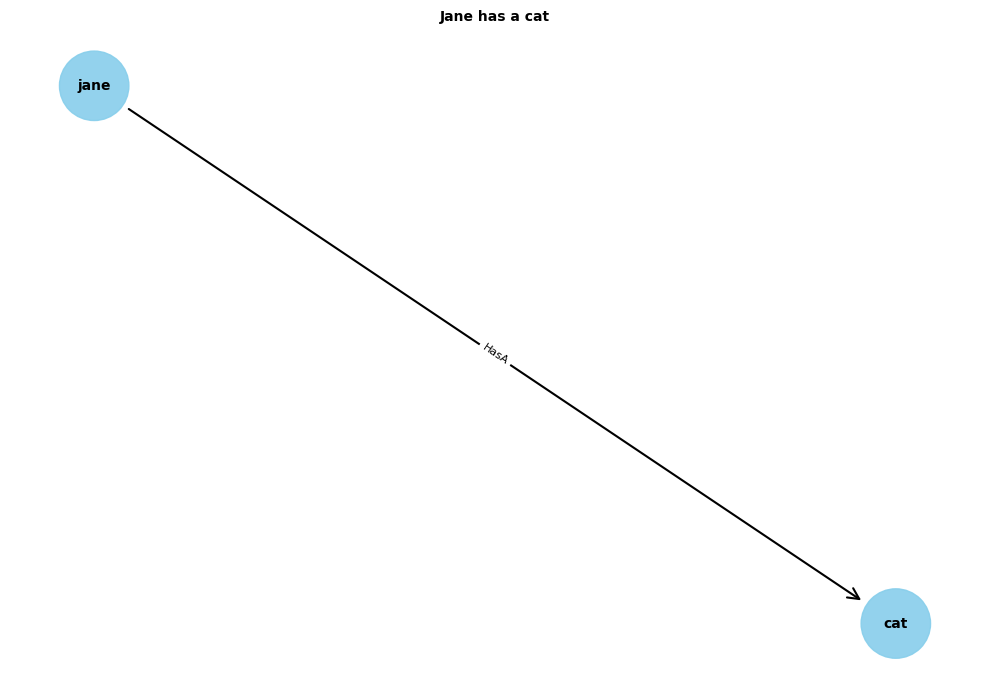

In [48]:
test_p = builder.build("Jane has a cat")
test_p.display()

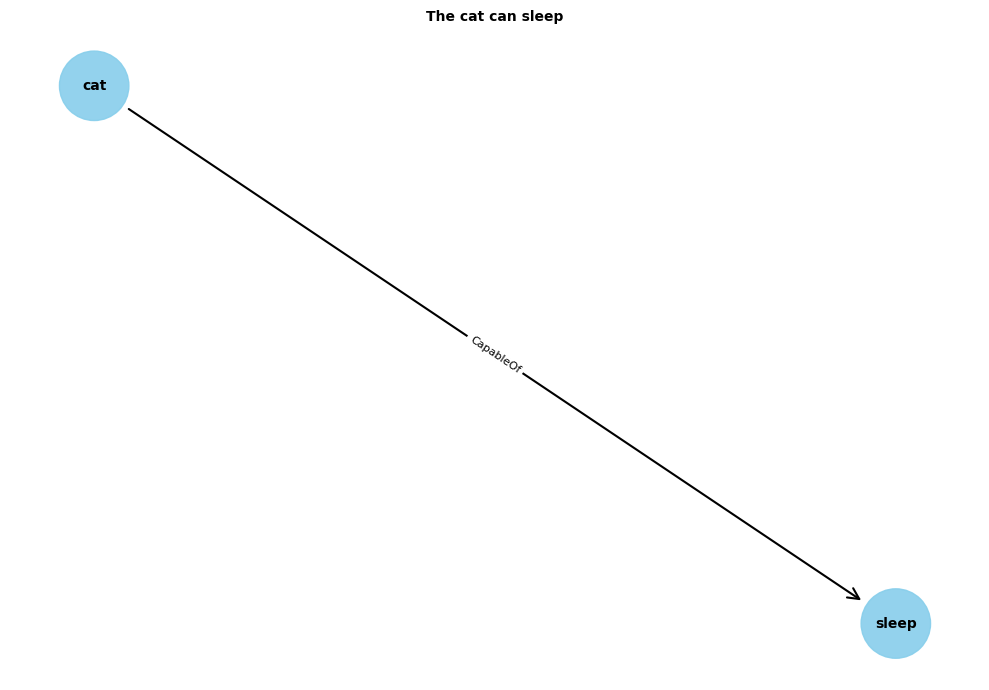

In [50]:
test_h = builder.build("The cat can sleep")
test_h.display()

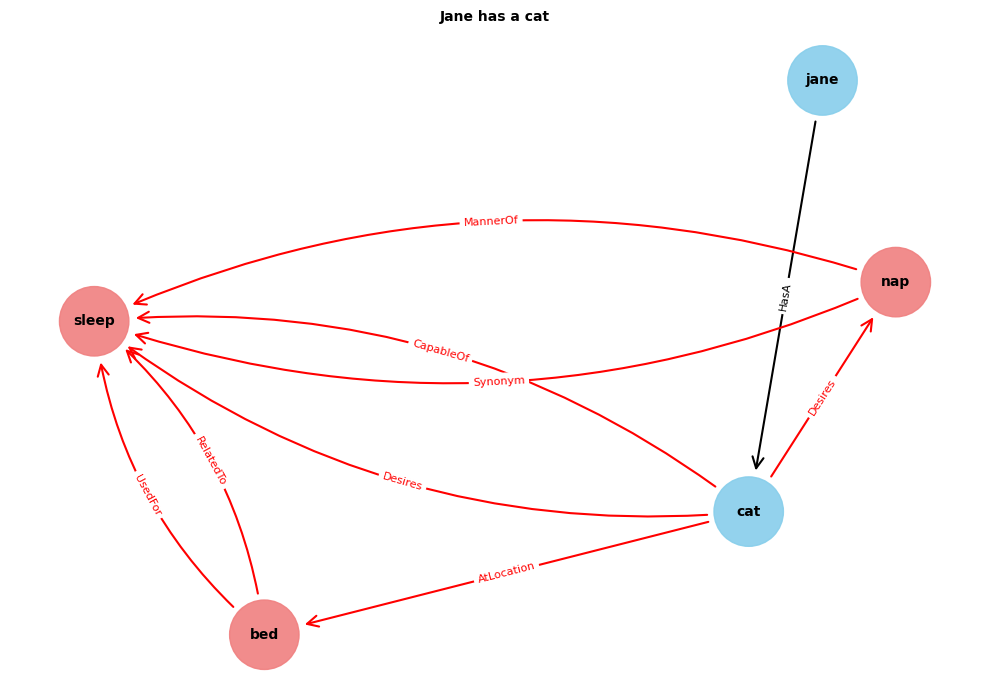

In [51]:
data_t_p = conceptGraph.get_rel_difference(test_p, test_h, dist = 2)
test_p.augment([(line[0],line[1],line[2])for line in data_t_p])
test_p.display()

Ici on voit le multi-hop, il y a des chemins qui sont directs, et d'autres qui prennent un intermediaire